# handwriting

> Read a handwritten hearing note and score the page.


The page is a lined hearing note in print, not cursive: a date, who was in the room, a direct-examination outline, and an objection. The file is `nbs/samples/hwr.png`. Margin labels, arrows, and the tier diagram are on the page.

The reference is those words, including the margin labels. Arrow strokes are not words, so they are left out. A line the model invents still counts against the error rate.


In [1]:
import re
import unicodedata

from fastcore.test import test_close, test_eq

REFERENCE = """
Date of Hearing
Tier Symbols
Page Number
9/8/23
Simpson
Client Name
1
In 2:30
Motion to Suppress
Hearing Description
Out 4:17
Attend
ME
Client (HS)
Prosecutor (LH)
Time Note for Billable Hours
Officer Wiggum (cw)
Judge Synder
Direct CW
Tier 1 Level
Background
Tier 2 Level
STIP Training and experience
Supervisor
Tier 3 Level
Day Shift
Review reports
Conduct officer discipline hearings
Date in question
Came in despite being sick
Impact
Memory
Question
Note
Recent concussion
Tier 4 Level
Diagnosed
Limited activity note from doctor
Desk duty review day shift reports
Reviewed reports for HS case
HS case review
Checked body cam
Checked cellebrite report
Discussion of report
OBJECTION Relevance and Hearsay Sustained
Objection Legal Note
Grounds
Outcome
"""

def normalize(text: str) -> str:
    "Letters and digits only, casefolded, so punctuation and line breaks do not count."
    folded = unicodedata.normalize("NFKC", text).casefold()
    return re.sub(r"\s+", " ", re.sub(r"[^0-9a-z]+", " ", folded)).strip()

def edit_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    previous = list(range(len(right) + 1))
    for i, a in enumerate(left, 1):
        current = [i]
        for j, b in enumerate(right, 1):
            current.append(min(current[-1] + 1, previous[j] + 1, previous[j - 1] + (a != b)))
        previous = current
    return previous[-1]

def lcs_length(left: str, right: str) -> int:
    previous = [0] * (len(right) + 1)
    for a in left:
        current = [0]
        for j, b in enumerate(right, 1):
            current.append(previous[j - 1] + 1 if a == b else max(current[-1], previous[j]))
        previous = current
    return previous[-1]

def score_text(hypothesis: str, reference: str) -> dict[str, float]:
    "Character and word error against `reference`. Recall ignores extra text; error does not."
    hyp = normalize(hypothesis)
    ref = normalize(reference)
    shared = lcs_length(hyp, ref)
    hyp_words, ref_words = hyp.split(), ref.split()
    return {
        "characters": float(len(ref)),
        "words": float(len(ref_words)),
        "cer": edit_distance(hyp, ref) / len(ref),
        "character_recall": shared / len(ref),
        "character_precision": shared / len(hyp) if hyp else 0.0,
        "wer": edit_distance(hyp_words, ref_words) / len(ref_words),
    }

test_eq(edit_distance("kitten", "sitting"), 3)
test_eq(edit_distance(["the", "cat"], ["the", "dog"]), 1)
test_eq(lcs_length("kitten", "sitting"), 4)
test_close(score_text("kitten", "sitting")["cer"], 3 / 7)
test_eq(normalize("M.J."), "m j")


## The scan

The file is `nbs/samples/hwr.png`. Cells from here on compile graphs, so a plain `nbdev-test` skips them.


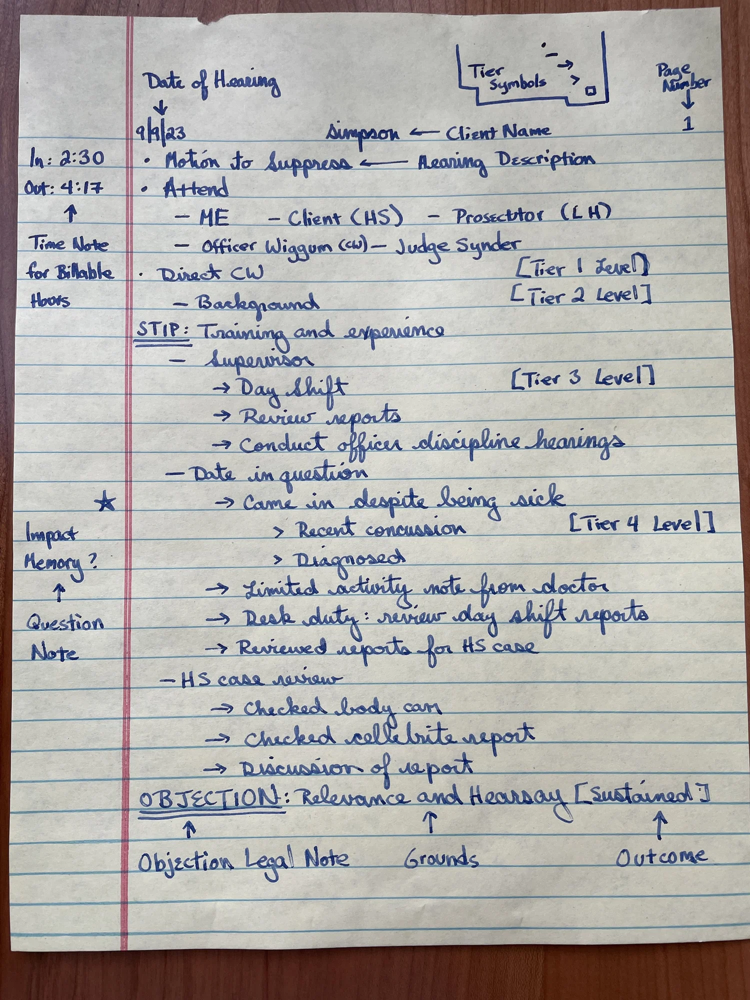

In [2]:
#| notest
import sys
from pathlib import Path
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

_root = Path.cwd()
if not (_root / "pixi.toml").is_file():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from solid_lens.core import repo_root

ROOT = repo_root()
PAGE = ROOT / "nbs" / "samples" / "hwr.png"

Image.open(PAGE)


## Read the page

One detector graph for this shape, then the shared 48×320 recognizer. The note is letterboxed, with its aspect kept, onto the 1056×1792 detector already compiled, so this cell opens that cache instead of building a new graph. The times after that are a warmup plus the median of five reads. Detection is one forward pass. Recognition is the sum of the line crops.


In [3]:
#| notest
import time

from solid_lens.model import compile_detector, compile_recognizer
import numpy as np

from solid_lens.ocr import (
    detection_hw,
    detect_boxes,
    load_charset,
    load_image,
    recognize_crop,
    resize_hwc,
)

def letterbox(image, out_h, out_w):
    "Scale to fit, then pad with white. The detector shape stays a multiple of 32."
    height, width = image.shape[:2]
    scale = min(out_w / width, out_h / height)
    fitted_h = max(1, int(round(height * scale)))
    fitted_w = max(1, int(round(width * scale)))
    fitted = resize_hwc(image, fitted_h, fitted_w)
    canvas = np.full((out_h, out_w, 3), 255, np.uint8)
    top = (out_h - fitted_h) // 2
    left = (out_w - fitted_w) // 2
    canvas[top:top + fitted_h, left:left + fitted_w] = fitted
    return canvas

image = letterbox(load_image(PAGE), 1792, 1056)
height, width = image.shape[:2]
det_h, det_w = detection_hw(height, width)
charset = load_charset(ROOT / "models" / "ppocrv6_dict.txt", add_space=True)

t0 = time.perf_counter()
detector = compile_detector(
    height=det_h,
    width=det_w,
    cache_dir=ROOT / "models" / f"native_medium_det_{det_h}x{det_w}.mef",
)
detector_ready = time.perf_counter() - t0
t0 = time.perf_counter()
recognizer = compile_recognizer(cache_dir=ROOT / "models" / "native_medium_rec_48x320.mef")
recognizer_ready = time.perf_counter() - t0
print(f"page {width}×{height} px, detector {det_w}×{det_h}")
print(f"detector ready in {detector_ready:.2f}s, recognizer ready in {recognizer_ready:.2f}s")

def read_timed(image):
    t0 = time.perf_counter()
    boxes = detect_boxes(image, detector)
    detect_s = time.perf_counter() - t0
    lines = []
    recognize_s = 0.0
    for left, top, right, bottom, score in boxes:
        t1 = time.perf_counter()
        text = recognize_crop(recognizer, image[top:bottom, left:right], charset)
        recognize_s += time.perf_counter() - t1
        if text:
            lines.append((text, score, left, top, right, bottom))
    return lines, detect_s, recognize_s

read_timed(image)
runs = [read_timed(image) for _ in range(5)]
lines, detect_s, recognize_s = min(runs, key=lambda run: run[1] + run[2])
detect_ms = sorted(run[1] for run in runs)[len(runs) // 2] * 1000
recognize_ms = sorted(run[2] for run in runs)[len(runs) // 2] * 1000
page_ms = sorted(run[1] + run[2] for run in runs)[len(runs) // 2] * 1000
print(f"{len(lines)} lines")
print(f"median detect {detect_ms:.0f} ms, recognize {recognize_ms:.0f} ms, page {page_ms:.0f} ms")


page 1056×1792 px, detector 1056×1792
detector ready in 0.77s, recognizer ready in 0.31s


54 lines
median detect 4312 ms, recognize 3103 ms, page 7588 ms


## Boxes

Each box is the axis-aligned crop the recognizer saw. The number matches the table. The score is the mean detector probability inside the quadrilateral, before recognition.


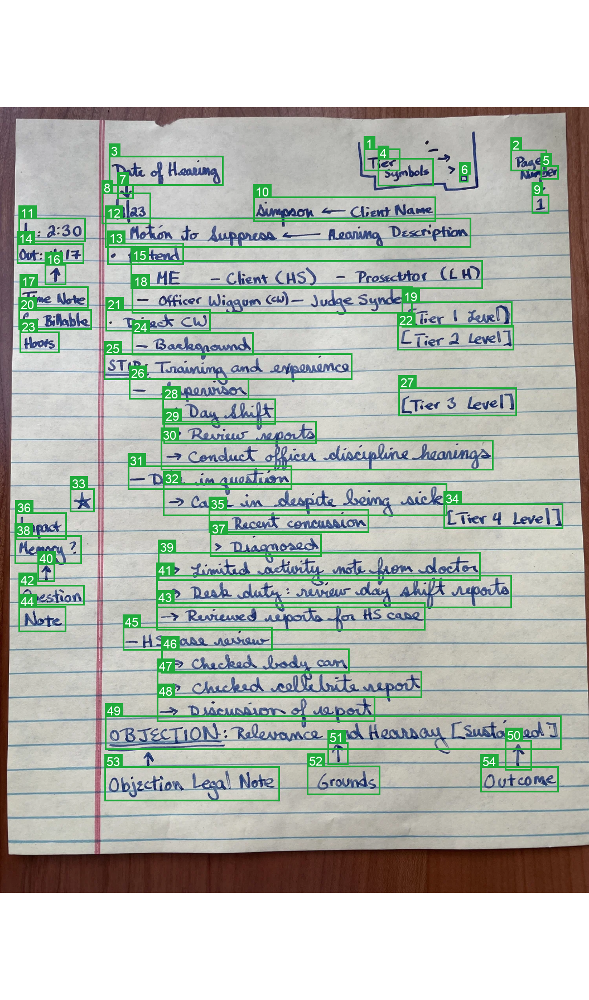

In [4]:
#| notest
def _font(size: int):
    for path in (
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/System/Library/Fonts/Helvetica.ttc",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ):
        if Path(path).is_file():
            return ImageFont.truetype(path, size)
    return ImageFont.load_default()

def draw_labeled(image, lines):
    canvas = Image.fromarray(image)
    draw = ImageDraw.Draw(canvas)
    font = _font(22)
    for index, (_, _, left, top, right, bottom) in enumerate(lines, 1):
        draw.rectangle([left, top, right, bottom], outline=(32, 170, 60), width=3)
        label = str(index)
        box = draw.textbbox((0, 0), label, font=font)
        tw, th = box[2] - box[0], box[3] - box[1]
        x, y = left, max(0, top - th - 6)
        draw.rectangle([x, y, x + tw + 8, y + th + 6], fill=(32, 170, 60))
        draw.text((x + 4, y + 2), label, fill=(255, 255, 255), font=font)
    return canvas

annotated = draw_labeled(image, lines)
annotated.save(PAGE.with_name(f"{PAGE.stem}.boxes.jpg"), quality=90)
annotated


In [5]:
#| notest
from IPython.display import Markdown

rows = ["| # | score | text |", "|---|------:|------|"]
for index, (text, score, *_) in enumerate(lines, 1):
    safe = text.replace("|", "\\|")
    rows.append(f"| {index} | {score:.2f} | {safe} |")
display(Markdown("\n".join(rows)))


| # | score | text |
|---|------:|------|
| 1 | 0.74 | Tier |
| 2 | 0.77 | Page |
| 3 | 0.91 | Date of Hearing |
| 4 | 0.79 | Symbols |
| 5 | 0.61 | ber |
| 6 | 0.69 | Q |
| 7 | 0.66 | V |
| 8 | 0.88 | 9k/23 |
| 9 | 0.85 | 1 |
| 10 | 0.87 | Simpson  Client Name |
| 11 | 0.90 | In:2:30 |
| 12 | 0.77 | Motion to suppressReaning Description |
| 13 | 0.93 | - Attend |
| 14 | 0.91 | Out:4:17 |
| 15 | 0.85 | -ME -Client (HS) - Prosecttor (LH) |
| 16 | 0.81 | ↑ |
| 17 | 0.88 | Time Note |
| 18 | 0.84 | - Officer Wiggum (aw)—Judge Synder |
| 19 | 0.91 | [Tier I Level) |
| 20 | 0.95 | for Billable |
| 21 | 0.87 | . Direct CW |
| 22 | 0.88 | [Tier 2 Level] |
| 23 | 0.94 | Hoors |
| 24 | 0.88 | - Backgound |
| 25 | 0.85 | STIP: Training and expevence |
| 26 | 0.88 | - supervisor |
| 27 | 0.87 | [Tier 3 Level] |
| 28 | 0.89 | →Day Shift |
| 29 | 0.88 | → Review reports |
| 30 | 0.81 | →Conduct officer discipline hearings |
| 31 | 0.87 | - Date in question |
| 32 | 0.81 | → came in despite being sick |
| 33 | 0.88 | ★ |
| 34 | 0.88 | [Tier 4 Level] |
| 35 | 0.86 | > Recent concussion |
| 36 | 0.92 | Impact |
| 37 | 0.90 | > Diagnosed |
| 38 | 0.92 | Memory? |
| 39 | 0.84 | Limited activity mote from doctor |
| 40 | 0.66 | 个 |
| 41 | 0.79 | Desk duty: revier day shift report |
| 42 | 0.94 | Question |
| 43 | 0.85 | → Reviewed reports for Hs case |
| 44 | 0.90 | Note |
| 45 | 0.86 | - Hs case review |
| 46 | 0.87 | → Checked body can |
| 47 | 0.81 | →checked cellebrite report |
| 48 | 0.89 | → Diicussion of report |
| 49 | 0.79 | OBJECTION: Relevance and Hearsay [Sustained I |
| 50 | 0.81 | ↑ |
| 51 | 0.87 | 个 |
| 52 | 0.84 | Grounds |
| 53 | 0.88 | Objection Legal Note |
| 54 | 0.90 | Outcome |

## Accuracy and speed

Character error rate is the Levenshtein distance divided by the length of the reference, after casefolding and dropping punctuation. A line the model adds makes that rate worse. Character recall is the longest common subsequence divided by the reference length, so it says how much of the note was recovered even when extra text was read.


In [6]:
#| notest
from IPython.display import Markdown

hypothesis = " ".join(text for text, *_ in lines)
metrics = score_text(hypothesis, REFERENCE)
summary = f"""
| | |
|---|---:|
| lines | {len(lines)} |
| reference characters | {metrics['characters']:.0f} |
| reference words | {metrics['words']:.0f} |
| character error rate | {metrics['cer']:.1%} |
| character recall | {metrics['character_recall']:.1%} |
| character precision | {metrics['character_precision']:.1%} |
| word error rate | {metrics['wer']:.1%} |
| detector, median | {detect_ms:.0f} ms |
| recognizer, median | {recognize_ms:.0f} ms |
| page, median | {page_ms:.0f} ms |
| detector graph ready | {detector_ready:.2f} s |
| recognizer graph ready | {recognizer_ready:.2f} s |
"""
display(Markdown(summary))
print(hypothesis)



| | |
|---|---:|
| lines | 54 |
| reference characters | 749 |
| reference words | 122 |
| character error rate | 25.5% |
| character recall | 85.4% |
| character precision | 85.7% |
| word error rate | 37.7% |
| detector, median | 4312 ms |
| recognizer, median | 3103 ms |
| page, median | 7588 ms |
| detector graph ready | 0.77 s |
| recognizer graph ready | 0.31 s |


Tier Page Date of Hearing Symbols ber Q V 9k/23 1 Simpson  Client Name In:2:30 Motion to suppressReaning Description - Attend Out:4:17 -ME -Client (HS) - Prosecttor (LH) ↑ Time Note - Officer Wiggum (aw)—Judge Synder [Tier I Level) for Billable . Direct CW [Tier 2 Level] Hoors - Backgound STIP: Training and expevence - supervisor [Tier 3 Level] →Day Shift → Review reports →Conduct officer discipline hearings - Date in question → came in despite being sick ★ [Tier 4 Level] > Recent concussion Impact > Diagnosed Memory? Limited activity mote from doctor 个 Desk duty: revier day shift report Question → Reviewed reports for Hs case Note - Hs case review → Checked body can →checked cellebrite report → Diicussion of report OBJECTION: Relevance and Hearsay [Sustained I ↑ 个 Grounds Objection Legal Note Outcome
